# CFPB complaints: what's in the text

2.36M consumer complaints with free text narratives. `src/nlp/prepare_complaints.py` cleans them in Spark and writes a 10% sample plus per state/product/month counts. This notebook looks at what came out, and at what the topic classifier learned.

Run order: prepare_complaints (in the spark container), then train_text_classifier, then this.

In [6]:
import os, sys

if os.path.exists("work/src"):
    os.chdir("work")
elif os.path.exists("../src"):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt

sample = pd.read_parquet("data/processed/complaints_sample")
stats = pd.read_parquet("data/processed/complaint_stats")
print(f"sample: {len(sample):,} narratives")
print(f"stats: {len(stats):,} state x product x month rows")

sample: 228,179 narratives
stats: 18,183 state x product x month rows


## What do people complain about?

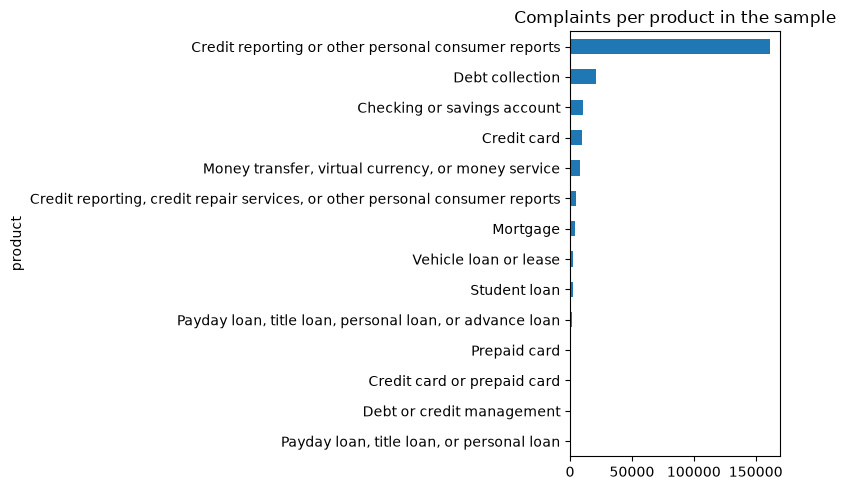

In [7]:
sample["product"].value_counts().sort_values().plot.barh(figsize=(8, 5))
plt.title("Complaints per product in the sample")
plt.tight_layout()
plt.show()

Credit reporting dominates by far. That imbalance matters for the classifier: without class weights it would learn to answer "credit reporting" to everything.

## Complaints per state

Raw counts mostly mirror population (California and Texas lead everything). The dashboard will normalize per capita to make states comparable.

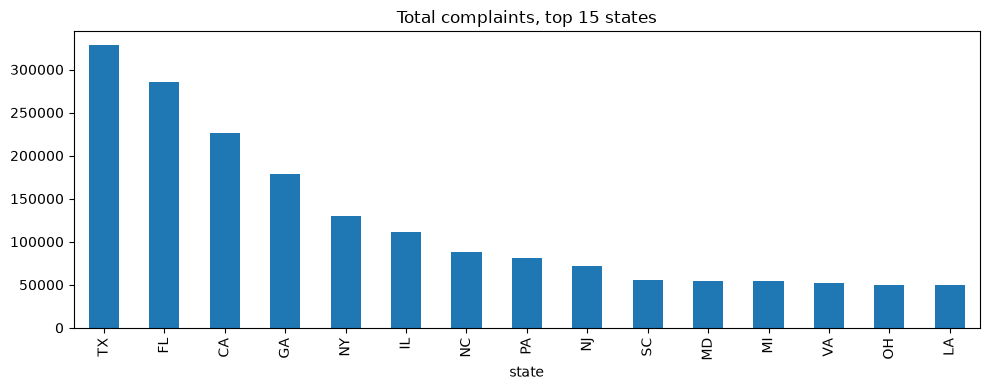

In [8]:
per_state = stats.groupby("state")["complaint_count"].sum().sort_values(ascending=False)
per_state.head(15).plot.bar(figsize=(10, 4), title="Total complaints, top 15 states")
plt.tight_layout()
plt.show()

## Read a few narratives

Always look at the raw data. The XXXX blocks are CFPB's redactions, the cleaning step strips most of them before training.

In [9]:
for _, row in sample.sample(3, random_state=7).iterrows():
    print(f"[{row['product']}] ({row['state']})")
    print(row["narrative"][:400])
    print("-" * 80)

[Credit reporting or other personal consumer reports] (GA)
I recently received a copy of my credit report and I noticed some accounts on my consumer report that should not be on there. 
This agency is in violation of 15 USC 1692g. They were to notify me of this in writing 5 days prior, I was not notified. As the original creditor, only I can validate this debt. I do not validate this debt. Therefore, the following accounts must be deleted from my report i
--------------------------------------------------------------------------------
[Credit reporting or other personal consumer reports] (LA)
I AM SUBMITTING THIS WITHOUT ANY INFLUENCE AND THIS IS NOT A THIRD PARTY. THE CREDIT BUREAUS STATED MY ACC WAS PROPERLY INVESTIGATED BUT HOW IS THAT POSSIBLE IF THE OPEN DATE IS INACCURATE, THE DATE LAST ACTIVE IS INACCURATE, AND THE DATE LAST REPORTED IS NOT ACCURATE? THIS GROUND FOR REMOVAL, THEY ALSO VIOLATED MY RIGHTS UNDER 15 U.S.C 1681 SECTION 602 A. STATES I HAVE THE RIGHT TO PRIVACY. 15 U.

## What did the classifier learn?

For a linear model on TF-IDF, the coefficients per class show which words push a narrative toward that label. Good sanity check that the model picked up real domain words and not noise.

In [10]:
import joblib
import numpy as np

pipe = joblib.load("models/complaint_topic_model.joblib")
vocab = np.array(pipe.named_steps["tfidf"].get_feature_names_out())
clf = pipe.named_steps["model"]

for i, label in enumerate(clf.classes_):
    top = vocab[np.argsort(clf.coef_[i])[-8:]][::-1]
    print(f"{label[:55]:55} -> {', '.join(top)}")

Checking or savings account                             -> bank, checking, account, cd, funds, debit card, overdraft, savings
Credit card                                             -> card, credit card, capital, citi, synchrony, discover, chase, credit
Credit card or prepaid card                             -> card, 2023, credit card, late, promotion, citi, chase, 23
Credit reporting or other personal consumer reports     -> equifax, experian, report, transunion, inquiries, credit, accounts, inquiry
Debt collection                                         -> debt, collection, collections, credit, owe, collect, credit report, owed
Debt or credit management                               -> debt, mortgage, credit, experian, debt relief, debts, settlement, lexington
Money transfers                                         -> zelle, money, coinbase, funds, paypal, cashapp, transfer, wire
Mortgage                                                -> mortgage, home, escrow, heloc, loan, foreclosu